# Bayesian hyperparameter search for learning the MET Efficiency space

In [1]:
import sys 
sys.path.append("../..")  # TODO: update with package install

import gpder
from gpder import plot_gpr
from gpder import GPKernelDerAware, GPKernel
from gpder import GaussianProcessRegressor
from gpder import BayesianOptimization

import uproot 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.stats as st
import pandas as pd

from numpy.linalg import det

from sklearn.metrics import mean_squared_error

Read the three-momenta of the photon and jet from "photon_jet.root"

The three-momenta of the jets are saved in the jet_threeM array.   
The three-momenta of the photons are saved in the photon_threeM array. 


In [2]:
f = uproot.open("./photon_jet.root")
tree = f['tnt']

photon_pt = np.asarray(tree['a_pt'].array())
photon_eta = np.asarray(tree['a_eta'].array())
photon_phi = np.asarray(tree['a_phi'].array())

jet_pt = np.asarray(tree['j_pt'].array())
jet_eta = np.asarray(tree['j_eta'].array())
jet_phi = np.asarray(tree['j_phi'].array())

photon_threeM = []
jet_threeM = []

nevents = photon_pt.shape[0]
for i in range(nevents):
    if ((photon_pt[i] > 20) and (jet_pt[i] > 20)):
        photon_threeM.append([photon_pt[i], photon_eta[i], photon_phi[i]])
        jet_threeM.append([jet_pt[i], jet_eta[i], jet_phi[i]])
        
photon_threeM = np.asarray(photon_threeM)
jet_threeM = np.asarray(jet_threeM)

f.close()

### Efficiency of MET < 10 

The function Eff_MET10_sigmoid below calculates the efficiency of the events with MET<10, given the photon and jet scale as the nuisance parameters.

The function dEff_MET10_sigmoid calculates the gradient of the efficiency with respect to the nuisance parameters.  

To have a differentiable function of the efficiency, a sigmoid function is used to approximaate the efficiency cuts. 

In [3]:
def sigmoid(X):
    return 1. / (1. + np.exp(-X))


def dsigmoid(X):
    return sigmoid(X) * (1 - sigmoid(X))

In [4]:
def Eff_MET10(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        if met < 10:
            count += 1
    return count / len(photon_threeM)


def Eff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        j_pt = jet_threeM[i, 0] / jet_scale
        met_x = a_pt * np.cos(photon_threeM[i, 2]) + j_pt * np.cos(jet_threeM[i, 2])
        met_y = a_pt * np.sin(photon_threeM[i, 2]) + j_pt * np.sin(jet_threeM[i, 2])
        met = np.sqrt(met_x * met_x + met_y * met_y)
        count += sigmoid(-(met-10.0))
    return count / len(photon_threeM)


def dEff_MET10_sigmoid(photon_scale, jet_scale, photon_threeM=photon_threeM, jet_threeM=jet_threeM):
    count_da = 0
    count_dj = 0
    for i in range(len(photon_threeM)):
        (pt_ix, eta_ix, phi_ix) = (1, 2, 3)
        a_pt = photon_threeM[i, 0] / photon_scale
        a_phi = photon_threeM[i, 2]
        j_pt = jet_threeM[i, 0] / jet_scale
        j_phi = jet_threeM[i, 2]
        met_x = a_pt * np.cos(a_phi) + j_pt * np.cos(j_phi)
        met_y = a_pt * np.sin(a_phi) + j_pt * np.sin(j_phi)
        met = np.sqrt(met_x * met_x + met_y * met_y)
        
        dsig = -dsigmoid(-(met-10.0))
        dmet = 0.5 / met 
        # wrt photon 
        dmet_da  = -2*met_x*photon_threeM[i, 0] * np.cos(a_phi) / photon_scale**2
        dmet_da += -2*met_y*photon_threeM[i, 0] * np.sin(a_phi) / photon_scale**2
        #wrt jet 
        dmet_dj  = -2*met_x*jet_threeM[i, 0] * np.cos(j_phi) / jet_scale**2
        dmet_dj += -2*met_y*jet_threeM[i, 0] * np.sin(j_phi) / jet_scale**2

        count_da += dsig * dmet * dmet_da
        count_dj += dsig * dmet * dmet_dj
        
    return [count_da / len(photon_threeM), count_dj / len(photon_threeM)]

### Regressing the MET space

We can learn to regress the MET space by using Gaussian Process Regression (GPR).

Starting with five training points, we compare the GPR with and without derivative information. 

In [5]:
# -- training points -- # 
nu_a_train = [0.7, 1.0, 1.0, 1.0, 1.3]
nu_j_tain = [1.0, 0.7, 1.0, 1.3, 1.0]
X_train = np.vstack((nu_a_train, nu_j_tain)).T
y_train = np.array([Eff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])
dy_train = np.array([dEff_MET10_sigmoid(nu_a_train[i], nu_j_tain[i]) for i in range(len(X_train))])

# -- testing points -- # 
res=10
X_lower = 0.5 
X_upper = 1.5
lin = np.linspace(X_lower, X_upper, res)
nu_a_test, nu_j_test = np.meshgrid(lin, lin)
X_test = np.vstack((nu_a_test.flatten(), nu_j_test.flatten())).T 
y_test = np.array([Eff_MET10_sigmoid(X_test[i][0], X_test[i][1]) for i in range(len(X_test))])

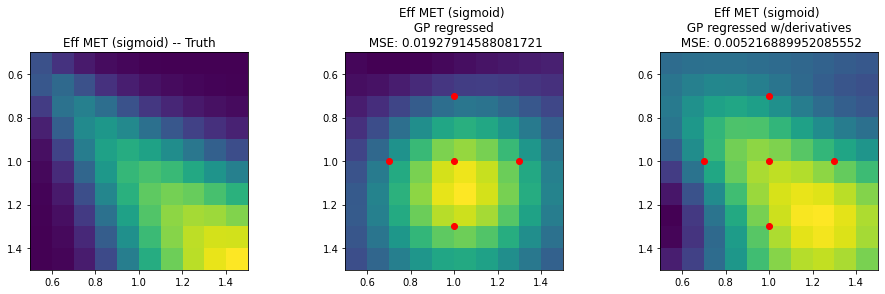

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
ax = axs.ravel()

axs[0].set_title("Eff MET (sigmoid) -- Truth")
axs[0].imshow(y_test.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])

# ----- Regular GP ----- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)

axs[1].set_title("Eff MET (sigmoid) \n GP regressed \n MSE: {}".format(mse))
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# -- Now with derivatives -- #
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train, dy=dy_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)

axs[2].set_title("Eff MET (sigmoid) \n GP regressed w/derivatives \n MSE: {}".format(mse))
axs[2].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[2].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

plt.savefig("MSE")

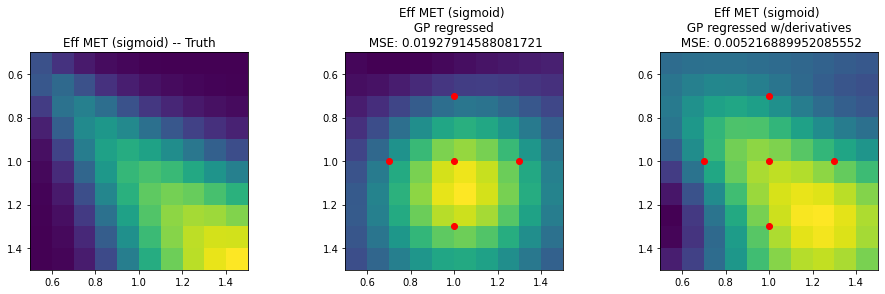

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
ax = axs.ravel()

axs[0].set_title("Eff MET (sigmoid) -- Truth")
axs[0].imshow(y_test.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
#axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# ----- Regular GP ----- #
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)

axs[1].set_title("Eff MET (sigmoid) \n GP regressed \n MSE: {}".format(mse))
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[1].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

# -- Now with derivatives -- #
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_train, y=y_train, dy=dy_train)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)

axs[2].set_title("Eff MET (sigmoid) \n GP regressed w/derivatives \n MSE: {}".format(mse))
axs[2].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[2].plot(X_train[:, 0], X_train[:, 1], "r.", ms=12)

plt.savefig("MSE")

### Using Bayes search to reduce the uncertainty of the GP regression

Now, we can use a bayes search to sample the space at the locations with high uncertainty. 

| Iter | photon_scale| jet_scale   | Target       |
| 0    | 0.700000    | 1.000000    | 0.187581     |
| 1    | 1.000000    | 0.700000    | 0.093411     |
| 2    | 1.000000    | 1.000000    | 0.373638     |
| 3    | 1.000000    | 1.300000    | 0.364020     |
| 4    | 1.300000    | 1.000000    | 0.272682     |
| 6    | 0.500000    | 1.500000    | 0.000752     |
| 7    | 1.500000    | 0.500000    | 0.000455     |
| 8    | 1.500000    | 1.500000    | 0.561721     |
| 9    | 0.500000    | 0.500000    | 0.140418     |
| 10   | 0.500000    | 1.000000    | 0.016654     |
| 11   | 1.500000    | 1.000000    | 0.186919     |
| 12   | 1.000000    | 1.500000    | 0.296450     |
| 13   | 1.000000    | 0.500000    | 0.007008     |
| 14   | 1.318211    | 0.681790    | 0.021183     |
| 15   | 0.500000    | 0.737629    | 0.091302     |
| 16   | 1.262975    | 1.500000    | 0.495781     |
| 17   | 1.500000    | 1.270810    | 0.449171     |
| 18   | 0.728433    | 0.500000    | 0.039184     |
| 19   | 0.7

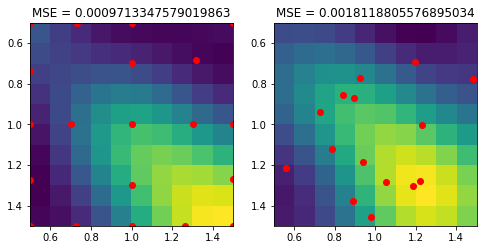

In [8]:
bayes = BayesianOptimization(fun=Eff_MET10_sigmoid,
                             param_bounds={'photon_scale': (0.5, 1.5),
                                           'jet_scale': (0.5, 1.5)},
                             random_state=123)

bayes.minimize_uncertainty(params_init=X_train, n_iters=15)


fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
axs[0].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[0].set_title("MSE = {}".format(mse))
axs[0].plot(bayes.params[:, 0], bayes.params[:, 1], "r.", ms=12)

# MSE of a GP after training it on randomly selected datapoints
np.random.seed(123)
nu_a_random = np.random.uniform(0.5, 1.5, 15)
np.random.seed(1234)
nu_j_random = np.random.uniform(0.5, 1.5, 15)
X_random = np.vstack((nu_a_random, nu_j_random)).T
y_random = np.array([Eff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
dy_random = np.array([dEff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
kernel = GPKernel()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_random, y=y_random)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[1].set_title("MSE = {}".format(mse))
axs[1].plot(X_random[:, 0], X_random[:, 1], "r.", ms=12)
plt.show()

And including derivative information...

| Iter | photon_scale| jet_scale   | Target       |
| 0    | 0.700000    | 1.000000    | 0.187581     |
| 1    | 1.000000    | 0.700000    | 0.093411     |
| 2    | 1.000000    | 1.000000    | 0.373638     |
| 3    | 1.000000    | 1.300000    | 0.364020     |
| 4    | 1.300000    | 1.000000    | 0.272682     |
| 6    | 1.500000    | 1.500000    | 0.561721     |
| 7    | 0.500000    | 1.500000    | 0.000752     |
| 8    | 1.500000    | 0.500000    | 0.000455     |
| 9    | 0.500000    | 0.500000    | 0.140418     |
| 10   | 1.500000    | 1.000004    | 0.186923     |
| 11   | 0.901268    | 0.500000    | 0.013690     |
| 12   | 0.500000    | 1.136039    | 0.006847     |
| 13   | 1.069368    | 1.500000    | 0.360603     |
| 14   | 0.500000    | 0.800924    | 0.061464     |
| 15   | 1.215191    | 0.500000    | 0.001636     |
| 16   | 0.771707    | 1.500000    | 0.074949     |
| 17   | 1.340994    | 1.287766    | 0.490112     |
| 18   | 1.385254    | 0.733784    | 0.029651     |
| 19   | 0.7

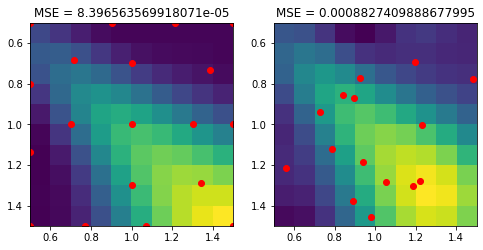

In [9]:
bayes = BayesianOptimization(fun=Eff_MET10_sigmoid,
                             dfun=dEff_MET10_sigmoid,
                             param_bounds={'photon_scale': (0.5, 1.5),
                                           'jet_scale': (0.5, 1.5)},
                             random_state=123)

bayes.minimize_uncertainty(params_init=X_train, n_iters=15)


fig, axs = plt.subplots(1, 2, figsize=(8, 4))
ax = axs.ravel()

# MSE of a GP after using bayes optimization to minimize uncertainty
mu, cov = bayes._gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
axs[0].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[0].set_title("MSE = {}".format(mse))
axs[0].plot(bayes.params[:, 0], bayes.params[:, 1], "r.", ms=12)

# MSE of a GP after training it on randomly selected datapoints
np.random.seed(123)
nu_a_random = np.random.uniform(0.5, 1.5, 15)
np.random.seed(1234)
nu_j_random = np.random.uniform(0.5, 1.5, 15)
X_random = np.vstack((nu_a_random, nu_j_random)).T
y_random = np.array([Eff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
dy_random = np.array([dEff_MET10_sigmoid(X_random[i][0], X_random[i][1]) for i in range(len(X_random))])
kernel = GPKernelDerAware()
gp = GaussianProcessRegressor(kernel=kernel,
                              n_restarts_optimizer=10, 
                              random_state=123)
gp.fit(X=X_random, y=y_random, dy=dy_random)
mu, cov = gp.predict(X=X_test, return_cov=True)
mse = mean_squared_error(mu, y_test)
axs[1].imshow(mu.reshape(res, res), origin='upper', extent=[0.5, 1.5, 1.5, 0.5])
axs[1].set_title("MSE = {}".format(mse))
axs[1].plot(X_random[:, 0], X_random[:, 1], "r.", ms=12)
plt.show()